# T007 · 基于配体的筛选：机器学习

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

* Jan Philipp Albrecht, CADD 研讨课 2018, Charité/FU Berlin
* Jaime Rodríguez-Guerra, 2019-2020, [Volkamer 实验室, Charité](https://volkamerlab.org/)
* Ingrid Vangone, 2022, [Volkamer 实验室, Charité](https://volkamerlab.org/)

__教程 T007__：本教程是 [第一篇 TeachOpenCADD 论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x)中描述的 TeachOpenCADD 流程的一部分，该流程包含教程 T001-T010。

## 本教程的目标

由于可用数据源越来越大，机器学习（ML）在药物发现，尤其是基于配体的虚拟筛选中发展迅速。本教程将学习如何使用不同的监督式 ML 算法预测新化合物对目标靶标（EGFR）的活性。

### _理论_ 部分内容

* 数据准备：分子编码
* 机器学习（ML）
    * 监督式学习
* 模型验证和评估
    * 验证策略：K 折交叉验证
    * 性能指标

### _实践_ 部分内容

* 加载化合物和活性数据
* 数据准备
    * 数据标注
    * 分子编码
* 机器学习
    * 辅助函数
    * 随机森林分类器
    * 支持向量分类器
    * 神经网络分类器
    * 交叉验证

### 参考文献

* “RDKit 中的指纹”[幻灯片](https://www.rdkit.org/UGM/2012/Landrum_RDKit_UGM.Fingerprints.Final.pptx.pdf)，G. Landrum, RDKit UGM 2012
* 扩展连通性指纹（ECFP）：Rogers, David, and Mathew Hahn. “Extended-connectivity fingerprints.” [*J. Chem. Inf. Model.* (2010), 50(5), 742-754](https://pubs.acs.org/doi/abs/10.1021/ci100050t)
* Mol2vec：Jaeger, Sabrina, Simone Fulle, and Samo Turk. “Mol2vec: unsupervised machine learning approach with chemical intuition.” [*J. Chem. Inf. Model.* (2018), 58(1), 27-35](https://pubs.acs.org/doi/10.1021/acs.jcim.7b00616)
* Scikit-learn 网站：[机器学习简介](http://scikit-learn.org/stable/tutorial/basic/tutorial.html#machine-learning-the-problem-setting) 和 [监督式学习](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning)
* 随机森林：[Wikipedia](https://en.wikipedia.org/wiki/Random_forest) 和 [scikit-learn](http://scikit-learn.org/stable/modules/ensemble.html#forest)
* 支持向量机：[Wikipedia](https://en.wikipedia.org/wiki/Support_vector_machine) 和 [scikit-learn](http://scikit-learn.org/stable/modules/svm.html)
* 人工神经网络：[Wikipedia](https://en.wikipedia.org/wiki/Artificial_neural_network) 和 [scikit-learn](http://scikit-learn.org/stable/modules/neural_networks_supervised.html)
* Chen, B., Harrison, R. F., Papadatos, G., Willett, P., Wood, D. J., Lewell, X. Q., ... & Storkey, A. J. (2007). Evaluation of machine-learning methods for ligand-based virtual screening. [*J. Comput. Aided Mol. Des.*, 21(1-3), 53-62](https://link.springer.com/article/10.1007/s10822-006-9096-5)
* See also TeachOpenCADD 教程 T010：What is the similarity of the approved EGFR inhibitors against each other? [GitHub notebook](https://github.com/volkamerlab/TeachOpenCADD/blob/master/teachopencadd/talktorials/T010_binding_site_comparison/talktorial.ipynb)

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 7
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

要成功应用 ML，我们需要一个大型分子数据集、一个分子编码、数据集中每个分子的标签，以及一个用于训练模型的 ML 算法。随后即可对新分子进行预测。

![ML overview](images/ML_overview.png)

*图 1*：机器学习概览：分子编码、标签、ML 算法和预测。图片由 Andrea Volkamer 提供。

### 数据准备：分子编码

对于 ML，需要将分子转换为特征列表。分子指纹常被用作表示。

本教程中使用的指纹均由 RDKit 实现（更多信息见 G. Landrum 的[报告幻灯片](https://www.rdkit.org/UGM/2012/Landrum_RDKit_UGM.Fingerprints.Final.pptx.pdf)）：

* MACCS 指纹：166 位结构关键字
* Morgan 指纹：圆形指纹，也称扩展连通性指纹（ECFP）

此外，还存在其他分子表示方法，例如分子描述符或图表示。

### 机器学习（ML）

ML 可以用于以下任务（文本改编自 [scikit-learn 页面](http://scikit-learn.org/stable/)）：

* **分类（监督式）**：识别对象所属类别（例如最近邻、朴素贝叶斯、RF、SVM 等）
* **回归**：预测与对象相关的连续值属性
* **聚类（无监督式）**：自动将相似对象分组到集合中（另见教程 T005）

在本教程中，我们使用监督式机器学习，并训练分类模型。

#### 监督式学习

学习算法通过在训练数据中发现模式来创建规则。

* **随机森林（RF）**：决策树的集成。单棵决策树会以最大化目标函数的方式划分输入向量的特征。在随机森林算法中，由于分裂特征是随机选择的，生成的树之间相关性较低。
* **支持向量机（SVM）**：SVM 可以通过所谓的核技巧有效执行非线性分类，将输入隐式映射到高维特征空间。该分类器的核心思想是最大化间隔。
* **人工神经网络（ANN）**：ANN 由互相连接的节点或神经元组成，这些节点之间传递信号并学习权重。

### 模型验证和评估

#### 验证策略：K 折交叉验证

* 这种模型验证技术以迭代方式将数据集分成两组：
    * 训练集：用于训练模型的已知数据
    * 测试集：用于测试模型的未知数据
    * 该过程重复 k 次
* 目标是测试模型预测未见数据的能力，识别已知的过拟合问题，并评估模型的泛化能力。

#### 性能指标

* **灵敏度**，也称真阳性率
    * TPR = TP/(FN + TP)
    * _直观理解_：在所有实际阳性样本中，有多少被预测为阳性？
* **特异性**，也称真阴性率
    * TNR = TN/(FP + TN)
    * _直观理解_：在所有实际阴性样本中，有多少被预测为阴性？
* **准确率**
    * ACC = (TP + TN) / (TP + FP + TN + FN)
    * _直观理解_：在所有预测中，有多少预测正确？
* **受试者工作特征曲线下面积**
    * ROC 曲线下面积（AUC）

| 模型预测 | 真实活性 | 真实非活性 |
|---|---|---|
| 活性 | 真阳性（TP） | 假阳性（FP） |
| 非活性 | 假阴性（FN） | 真阴性（TN） |

## 实践

In [2]:
from pathlib import Path
from warnings import filterwarnings
import time

import pandas as pd
import numpy as np
from sklearn import svm, metrics, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import auc, accuracy_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import MACCSkeys, rdFingerprintGenerator

# 静默一些预期警告
filterwarnings("ignore")
# 固定随机种子以获得可重复结果
SEED = 22
np.random.seed(SEED)

In [3]:
# 设置当前 notebook 的路径
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 加载化合物和活性数据

首先加载我们的数据，该数据聚焦于表皮生长因子受体（EGFR）激酶。来自 **教程 T002** 的 *csv* 文件被加载为包含重要列的数据框：

* ChEMBL ID
* 对应化合物的 SMILES 字符串
* 测得亲和力：pIC50

In [4]:
# 读取前序教程的数据
chembl_df = pd.read_csv(
    DATA / "EGFR_compounds_lipinski.csv",
    index_col=0,
)

# 查看前几行
print("Shape of dataframe : ", chembl_df.shape)
chembl_df.head()
# NBVAL_CHECK_OUTPUT

Shape of dataframe :  (4635, 10)


,molecule_chembl_id,IC50,units,smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,349.021459,3,1,5.2891,True
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,387.058239,5,1,4.9333,True
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,343.043258,5,1,3.5969,True
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,339.011957,4,2,4.0122,True
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,329.027607,5,2,3.5726,True


In [5]:
# 仅保留需要的列
chembl_df = chembl_df[["molecule_chembl_id", "smiles", "pIC50"]]
chembl_df.head()
# NBVAL_CHECK_OUTPUT

,molecule_chembl_id,smiles,pIC50
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
3,CHEMBL66031,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910
4,CHEMBL53753,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


### 数据准备

#### 数据标注
我们需要将每个化合物分类为活性或非活性。因此，使用 pIC50 值。

* pIC50 = -log10(IC50)
* IC50 描述了在 *体外* 将某一过程抑制 50% 所需的物质量。
* 离散化 pIC50 数据的常用阈值为 6.3，本实验也采用该值（参见 [<i>J. Med. Chem.</i> (2017), <b>60</b>, 474-485](https://pubs.acs.org/doi/abs/10.1021/acs.jmedchem.6b01611)）。

In [6]:
# 添加活性列
chembl_df["active"] = np.zeros(len(chembl_df))

# 将 pIC50 >= 6.3 的分子标记为活性，否则标记为 0
chembl_df.loc[chembl_df[chembl_df.pIC50 >= 6.3].index, "active"] = 1.0

# NBVAL_CHECK_OUTPUT
print("Number of active compounds:", int(chembl_df.active.sum()))
print("Number of inactive compounds:", len(chembl_df) - int(chembl_df.active.sum()))

Number of active compounds: 2631
Number of inactive compounds: 2004


In [7]:
chembl_df.head()
# NBVAL_CHECK_OUTPUT

,molecule_chembl_id,smiles,pIC50,active
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,1.0
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,1.0
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,1.0
3,CHEMBL66031,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,1.0
4,CHEMBL53753,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,1.0


#### 分子编码

现在定义函数 `smiles_to_fp`，从 SMILES 生成指纹。目前支持以下指纹：

* MACCS
* Morgan2 和 Morgan3

In [8]:
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    将 SMILES 字符串编码为分子指纹。

    Parameters
    ----------
    smiles : str
        定义分子的 SMILES 字符串。

    method : str
        使用的指纹类型。默认使用 MACCS keys。

    n_bits : int
        指纹长度。

    Returns
    -------
    array
        指纹数组。

    """

    # 将 SMILES 转换为 RDKit Mol 对象
    mol = Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetFingerprint(mol))
    else:
        # NBVAL_CHECK_OUTPUT
        print(f"Warning: Wrong method specified: {method}. Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [9]:
compound_df = chembl_df.copy()

In [10]:
# 添加指纹列
compound_df["fp"] = compound_df["smiles"].apply(smiles_to_fp)
compound_df.head(3)
# NBVAL_CHECK_OUTPUT

,molecule_chembl_id,smiles,pIC50,active,fp
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


### 机器学习（ML）

下面将尝试多种 ML 方法来分类分子。我们将使用：

* 随机森林（RF）
* 支持向量机（SVM）
* 人工神经网络（ANN）

此外，我们会对结果进行评论。

目标是测试模型预测未见数据的能力，识别过拟合问题，并评估模型的泛化能力。

首先定义函数 `model_training_and_validation`，用于训练和评估模型。

#### 辅助函数
用于绘制自定义 ROC 曲线的辅助函数。代码灵感来自 [StackOverflow](https://stackoverflow.com/questions/42894871/how-to-plot-multiple-roc-curves-in-one-plot-with-legend-and-auc-scores-in-python)。

In [11]:
def plot_roc_curves_for_models(models, test_x, test_y, save_png=False):
    """
    用于绘制自定义 ROC 曲线的辅助函数。

    Parameters
    ----------
    models: dict
        预训练机器学习模型字典。
    test_x: list
        测试集的分子指纹。
    test_y: list
        测试集对应的活性标签。
    save_png: bool
        是否将图像保存到磁盘（默认 = False）。

    Returns
    -------
    fig:
        图。
    """

    fig, ax = plt.subplots()

    # 下方循环遍历模型列表
    for model in models:
        # 选择模型
        ml_model = model["model"]
        # 测试集上的预测概率
        test_prob = ml_model.predict_proba(test_x)[:, 1]
        # 测试集上的预测类别
        test_pred = ml_model.predict(test_x)
        # 计算假阳性率和真阳性率
        fpr, tpr, thresholds = metrics.roc_curve(test_y, test_prob)
        # 计算曲线下面积并显示在图中
        auc = roc_auc_score(test_y, test_prob)
        # 绘制计算结果
        ax.plot(fpr, tpr, label=(f"{model['label']} AUC area = {auc:.2f}"))

    # Custom settings for the plot
    ax.plot([0, 1], [0, 1], "r--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Receiver Operating Characteristic")
    ax.legend(loc="lower right")
    # Save plot
    if save_png:
        fig.savefig(f"{DATA}/roc_auc", dpi=300, bbox_inches="tight", transparent=True)
    return fig

用于计算模型性能的辅助函数。

In [12]:
def model_performance(ml_model, test_x, test_y, verbose=True):
    """
    用于计算模型性能的辅助函数

    Parameters
    ----------
    ml_model: sklearn model object
        要训练的机器学习模型。
    test_x: list
        测试集的分子指纹。
    test_y: list
        测试集对应的活性标签。
    verbose: bool
        是否打印性能指标（默认 = True）。

    Returns
    -------
    tuple:
        测试集上的准确率、灵敏度、特异性和 AUC。
    """

    # 测试集上的预测概率
    test_prob = ml_model.predict_proba(test_x)[:, 1]

    # 测试集上的预测类别
    test_pred = ml_model.predict(test_x)

    # 模型在测试集上的性能
    accuracy = accuracy_score(test_y, test_pred)
    sens = recall_score(test_y, test_pred)
    spec = recall_score(test_y, test_pred, pos_label=0)
    auc = roc_auc_score(test_y, test_prob)

    if verbose:
        # 打印性能结果
        # NBVAL_CHECK_OUTPUT        print(f"Accuracy: {accuracy:.2}")
        print(f"Sensitivity: {sens:.2f}")
        print(f"Specificity: {spec:.2f}")
        print(f"AUC: {auc:.2f}")

    return accuracy, sens, spec, auc

用于在随机训练-测试拆分上拟合机器学习模型，并返回性能指标的辅助函数。

In [13]:
def model_training_and_validation(ml_model, name, splits, verbose=True):
    """
    在数据的随机训练-测试拆分上拟合机器学习模型，
    并返回性能指标。

    Parameters
    ----------
    ml_model: sklearn model object
        要训练的机器学习模型。
    name: str
        机器学习算法名称：RF、SVM、ANN。
    splits: list
        描述符和标签数据列表：train_x、test_x、train_y、test_y。
    verbose: bool
        是否打印性能信息（默认 = True）。

    Returns
    -------
    tuple:
        测试集上的准确率、灵敏度、特异性和 AUC。

    """
    train_x, test_x, train_y, test_y = splits

    # 拟合模型
    ml_model.fit(train_x, train_y)

    # 计算模型性能结果
    accuracy, sens, spec, auc = model_performance(ml_model, test_x, test_y, verbose)

    return accuracy, sens, spec, auc

**预处理**：拆分数据（后续模型会复用）。

In [14]:
fingerprint_to_model = compound_df.fp.tolist()
label_to_model = compound_df.active.tolist()

# 随机拆分训练集和测试集
# 注意 test/train_x 对应指纹拆分
# test/train_y 对应标签拆分
(
    static_train_x,
    static_test_x,
    static_train_y,
    static_test_y,
) = train_test_split(fingerprint_to_model, label_to_model, test_size=0.2, random_state=SEED)
splits = [static_train_x, static_test_x, static_train_y, static_test_y]
# NBVAL_CHECK_OUTPUT
print("Training data size:", len(static_train_x))
print("Test data size:", len(static_test_x))

Training data size: 3708
Test data size: 927


#### 随机森林分类器

从随机森林分类器开始，首先设置参数。

在随机训练-测试拆分上训练模型并绘制结果。

In [15]:
# 设置随机森林模型参数
param = {
    "n_estimators": 100,  # 生成的树数量
    "criterion": "entropy",  # 分裂时优化的代价函数
}
model_RF = RandomForestClassifier(**param)

In [16]:
# 在单次拆分上拟合模型
performance_measures = model_training_and_validation(model_RF, "RF", splits)

Sensitivity: 0.90
Specificity: 0.77
AUC: 0.90


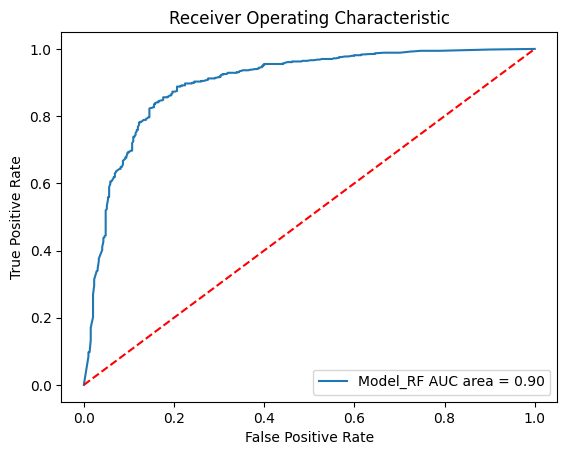

In [17]:
# 初始化存储所有模型的列表，第一个为 RF
models = [{"label": "Model_RF", "model": model_RF}]
# 绘制 ROC 曲线
plot_roc_curves_for_models(models, static_test_x, static_test_y);

#### 支持向量分类器
这里使用径向基函数核（也称平方指数核）训练 SVM。

更多信息请参见 [sklearn RBF kernel](http://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.RBF.html)。

In [18]:
# 指定模型
model_SVM = svm.SVC(kernel="rbf", C=1, gamma=0.1, probability=True)

# 在单次拆分上拟合模型
performance_measures = model_training_and_validation(model_SVM, "SVM", splits)

Sensitivity: 0.92
Specificity: 0.74
AUC: 0.90


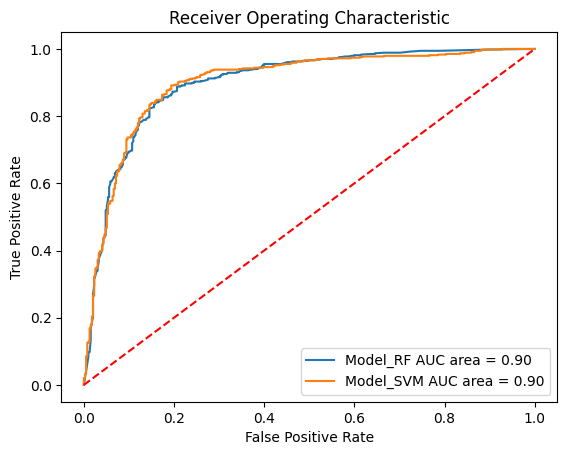

In [19]:
# 添加 SVM 模型
models.append({"label": "Model_SVM", "model": model_SVM})
# 绘制 ROC 曲线
plot_roc_curves_for_models(models, static_test_x, static_test_y);

#### 神经网络分类器
最后尝试神经网络模型。我们训练一个 MLPClassifier（多层感知器分类器），包含 2 层：第一层 5 个神经元，第二层 3 个神经元。和之前一样，我们执行交叉验证过程并绘制结果。更多 MLP 信息见 [sklearn MLPClassifier](http://scikit-learn.org/stable/modules/neural_networks_supervised.html)。

In [20]:
# 指定模型
model_ANN = MLPClassifier(hidden_layer_sizes=(5, 3), random_state=SEED)

# 在单次拆分上拟合模型
performance_measures = model_training_and_validation(model_ANN, "ANN", splits)

Sensitivity: 0.85
Specificity: 0.73
AUC: 0.86


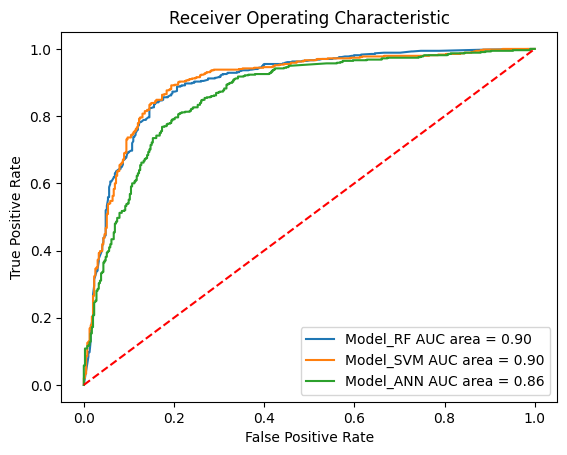

In [21]:
# 添加 ANN 模型
models.append({"label": "Model_ANN", "model": model_ANN})
# 绘制 ROC 曲线
plot_roc_curves_for_models(models, static_test_x, static_test_y, True);

我们的模型在所有指标上都显示出较好的数值（见 AUC），因此看起来具有预测能力。

#### 交叉验证

接下来，将使用三种不同模型进行交叉验证实验。因此，我们定义一个辅助函数，在交叉验证循环中完成机器学习模型的训练和验证。

In [22]:
def crossvalidation(ml_model, df, n_folds=5, verbose=False):
    """
    在交叉验证循环中训练并验证机器学习模型。

    Parameters
    ----------
    ml_model: sklearn model object
        要训练的机器学习模型。
    df: pd.DataFrame
        包含 SMILES 及其对应活性标签的数据集。
    n_folds: int, optional
        交叉验证折数。
    verbose: bool, optional
        是否打印性能指标。

    Returns
    -------
    None

    """
    t0 = time.time()
    # 为 K 折交叉验证打乱索引
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)

    # 每个交叉验证折的结果
    acc_per_fold = []
    sens_per_fold = []
    spec_per_fold = []
    auc_per_fold = []

    # 遍历各折
    for train_index, test_index in kf.split(df):
        # 克隆模型，每一折都需要一个全新副本
        fold_model = clone(ml_model)
        # 训练

        # 将指纹和标签转换为列表
        train_x = df.iloc[train_index].fp.tolist()
        train_y = df.iloc[train_index].active.tolist()

        # 拟合模型
        fold_model.fit(train_x, train_y)

        # 测试

        # 将指纹和标签转换为列表
        test_x = df.iloc[test_index].fp.tolist()
        test_y = df.iloc[test_index].active.tolist()

        # Performance for each fold
        accuracy, sens, spec, auc = model_performance(fold_model, test_x, test_y, verbose)

        # 保存结果
        acc_per_fold.append(accuracy)
        sens_per_fold.append(sens)
        spec_per_fold.append(spec)
        auc_per_fold.append(auc)

    # 打印结果统计信息
    print(
        f"Mean accuracy: {np.mean(acc_per_fold):.2f} \t"
        f"and std : {np.std(acc_per_fold):.2f} \n"
        f"Mean sensitivity: {np.mean(sens_per_fold):.2f} \t"
        f"and std : {np.std(sens_per_fold):.2f} \n"
        f"Mean specificity: {np.mean(spec_per_fold):.2f} \t"
        f"and std : {np.std(spec_per_fold):.2f} \n"
        f"Mean AUC: {np.mean(auc_per_fold):.2f} \t"
        f"and std : {np.std(auc_per_fold):.2f} \n"
        f"Time taken : {time.time() - t0:.2f}s\n"
    )

    return acc_per_fold, sens_per_fold, spec_per_fold, auc_per_fold

**交叉验证**

现在应用交叉验证，并展示三个 ML 模型的统计结果。在真实场景中，交叉验证通常使用 5 折或更多折；但出于性能考虑，这里减少为 3 折。你可以在下面的单元格中更改 `N_FOLDS`。

In [23]:
N_FOLDS = 3

_注意_：下一个单元格执行时间较长。

In [24]:
for model in models:
    print("\n======= ")
    print(f"{model['label']}")
    crossvalidation(model["model"], compound_df, n_folds=N_FOLDS)


Model_RF
Mean accuracy: 0.83 	and std : 0.01 
Mean sensitivity: 0.88 	and std : 0.02 
Mean specificity: 0.76 	and std : 0.01 
Mean AUC: 0.89 	and std : 0.01 
Time taken : 1.59s


Model_SVM
Mean accuracy: 0.84 	and std : 0.01 
Mean sensitivity: 0.90 	and std : 0.01 
Mean specificity: 0.76 	and std : 0.00 
Mean AUC: 0.89 	and std : 0.01 
Time taken : 13.47s


Model_ANN
Mean accuracy: 0.81 	and std : 0.00 
Mean sensitivity: 0.86 	and std : 0.01 
Mean specificity: 0.73 	and std : 0.01 
Mean AUC: 0.87 	and std : 0.00 
Time taken : 4.21s



接下来查看使用 Morgan 指纹而非 MACCS keys 编码的分子的交叉验证性能。

In [25]:
# 重置数据框
compound_df = chembl_df.copy()

In [26]:
# 使用半径为 3 的 Morgan 指纹
compound_df["fp"] = compound_df["smiles"].apply(smiles_to_fp, args=("morgan3",))
compound_df.head(3)
# NBVAL_CHECK_OUTPUT

,molecule_chembl_id,smiles,pIC50,active,fp
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


_注意_：下一个单元格执行时间较长。

In [27]:
for model in models:
    if model["label"] == "Model_SVM":
        # SVM 在长指纹上非常慢
        # 且性能通常与 RF 相近
        # 因此本测试中可以跳过它；如果想运行
        # 可将 `continue` 替换为 `pass`
        continue
    print("\n=======")
    print(model["label"])
    crossvalidation(model["model"], compound_df, n_folds=N_FOLDS)


Model_RF
Mean accuracy: 0.86 	and std : 0.01 
Mean sensitivity: 0.90 	and std : 0.01 
Mean specificity: 0.81 	and std : 0.00 
Mean AUC: 0.92 	and std : 0.01 
Time taken : 4.75s


Model_ANN
Mean accuracy: 0.81 	and std : 0.01 
Mean sensitivity: 0.84 	and std : 0.01 
Mean specificity: 0.77 	and std : 0.00 
Mean AUC: 0.88 	and std : 0.01 
Time taken : 11.43s



## 讨论

* 哪个模型在我们的数据集上表现最好，为什么？
    * 三个模型在该数据集上的表现都（非常）好。表现最好的模型是随机森林和支持向量机，平均 AUC 约为 90%。神经网络的结果略低。
    * 随机森林和支持向量机表现最好可能有多种原因。该数据集可能可以通过较简单的树状决策或径向基函数很好地区分活性和非活性化合物。
* 数据集规模对模型表现有什么影响？
    * 数据集越大，通常越能训练出泛化能力更好的模型。
* 为什么需要交叉验证？
    * 交叉验证可以减少单次随机训练-测试划分带来的偶然性，并更稳定地估计模型性能。

## 测验

* 如何将 ML 应用于虚拟筛选？
* 你了解哪些机器学习算法？
* 成功应用 ML 需要哪些必要前提？